# WeatherPy

---

## Starter Code to Generate Random Geographic Coordinates and a List of Cities

In [69]:
# Dependencies and Setup
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import requests
import time
from scipy.stats import linregress

# Impor the OpenWeatherMap API key
from api_keys import weather_api_key

# Import citipy to determine the cities based on latitude and longitude
from citipy import citipy

### Generate the Cities List by Using the `citipy` Library

In [70]:
# Empty list for holding the latitude and longitude combinations
lat_lngs = []

# Empty list for holding the cities names
cities = []

# Range of latitudes and longitudes
lat_range = (-90, 90)
lng_range = (-180, 180)

# Create a set of random lat and lng combinations
lats = np.random.uniform(lat_range[0], lat_range[1], size=1500)
lngs = np.random.uniform(lng_range[0], lng_range[1], size=1500)
lat_lngs = zip(lats, lngs)

# Identify nearest city for each lat, lng combination
for lat_lng in lat_lngs:
    city = citipy.nearest_city(lat_lng[0], lat_lng[1]).city_name

    # If the city is unique, then add it to a our cities list
    if city not in cities:
        cities.append(city)

# Print the city count to confirm sufficient count
print(f"Number of cities in the list: {len(cities)}")

Number of cities in the list: 615


---

## Requirement 1: Create Plots to Showcase the Relationship Between Weather Variables and Latitude

### Use the OpenWeatherMap API to retrieve weather data from the cities list generated in the started code

In [71]:
# Set the API base URL
url = "https://api.openweathermap.org/data/2.5/weather?"

# Define an empty list to fetch the weather data for each city
city_data = []

# Print to logger
print("Beginning Data Retrieval     ")
print("-----------------------------")

# Create counters
record_count = 1
set_count = 1

# Loop through all the cities in our list to fetch weather data
for i, city in enumerate(cities):

    # Group cities in sets of 50 for logging purposes
    if (i % 50 == 0 and i >= 50):
        set_count += 1
        record_count = 0

    # Create endpoint URL with each city
    city_url = f"{url}appid={weather_api_key}&q={city}&units=metric"

    # Log the url, record, and set numbers
    print("Processing Record %s of Set %s | %s" % (record_count, set_count, city))

    # Add 1 to the record count
    record_count += 1

    # Run an API request for each of the cities
    try:
        # Parse the JSON and retrieve data
        city_weather = requests.get(city_url).json()

        # Parse out latitude, longitude, max temp, humidity, cloudiness, wind speed, country, and date
        city_lat = city_weather["coord"]["lat"]
        city_lng = city_weather["coord"]["lon"]
        city_max_temp = city_weather["main"]["temp_max"]
        city_humidity = city_weather["main"]["humidity"]
        city_clouds = city_weather["clouds"]["all"]
        city_wind = city_weather["wind"]["speed"]
        city_country = city_weather["sys"]["country"]
        city_date = city_weather["dt"]

        # Append the City information into city_data list
        city_data.append({"City": city,
                          "Lat": city_lat,
                          "Lng": city_lng,
                          "Max Temp": city_max_temp,
                          "Humidity": city_humidity,
                          "Cloudiness": city_clouds,
                          "Wind Speed": city_wind,
                          "Country": city_country,
                          "Date": city_date})

    # If an error is experienced, skip the city
    except:
        print("City not found. Skipping...")
        pass

    # pause to avoid rate limiting
    time.sleep(1)

# Indicate that Data Loading is complete
print("-----------------------------")
print("Data Retrieval Complete      ")
print("-----------------------------")

Beginning Data Retrieval     
-----------------------------
Processing Record 1 of Set 1 | keflavik
Processing Record 2 of Set 1 | bethel
Processing Record 3 of Set 1 | margaret river
Processing Record 4 of Set 1 | new plymouth
Processing Record 5 of Set 1 | ushuaia
Processing Record 6 of Set 1 | avarua
Processing Record 7 of Set 1 | atafu village
Processing Record 8 of Set 1 | ribeira grande
Processing Record 9 of Set 1 | port-aux-francais
Processing Record 10 of Set 1 | whitehorse
Processing Record 11 of Set 1 | nabire
Processing Record 12 of Set 1 | laguna
Processing Record 13 of Set 1 | badger
Processing Record 14 of Set 1 | kolonia town
Processing Record 15 of Set 1 | bathsheba
Processing Record 16 of Set 1 | waitangi
Processing Record 17 of Set 1 | olonkinbyen
Processing Record 18 of Set 1 | kayar
Processing Record 19 of Set 1 | bardai
Processing Record 20 of Set 1 | siocon
Processing Record 21 of Set 1 | luderitz
Processing Record 22 of Set 1 | howrah
Processing Record 23 of Set

In [72]:
# Convert the cities weather data into a Pandas DataFrame
city_data_df = pd.DataFrame(city_data)

# Show Record Count
city_data_df.count()

City          589
Lat           589
Lng           589
Max Temp      589
Humidity      589
Cloudiness    589
Wind Speed    589
Country       589
Date          589
dtype: int64

In [73]:
# Display sample data
city_data_df.head()

,City,Lat,Lng,Max Temp,Humidity,Cloudiness,Wind Speed,Country,Date
0,keflavik,64.0049,-22.5624,1.24,93,75,5.14,IS,1739062856
1,bethel,41.3712,-73.4140,-0.55,62,100,1.79,US,1739062801
2,margaret river,-33.9500,115.0667,21.69,69,18,6.32,AU,1739062859
3,new plymouth,-39.0667,174.0833,21.84,100,0,4.03,NZ,1739062860
4,ushuaia,-54.8000,-68.3000,8.81,71,40,6.69,AR,1739062628


In [74]:
# Export the City_Data into a csv
city_data_df.to_csv("output_data/cities.csv", index_label="City_ID")

In [75]:
# Read saved data
city_data_df = pd.read_csv("output_data/cities.csv", index_col="City_ID")

# Display sample data
city_data_df.head()

,City,Lat,Lng,Max Temp,Humidity,Cloudiness,Wind Speed,Country,Date
City_ID,,,,,,,,,
0,keflavik,64.0049,-22.5624,1.24,93,75,5.14,IS,1739062856
1,bethel,41.3712,-73.4140,-0.55,62,100,1.79,US,1739062801
2,margaret river,-33.9500,115.0667,21.69,69,18,6.32,AU,1739062859
3,new plymouth,-39.0667,174.0833,21.84,100,0,4.03,NZ,1739062860
4,ushuaia,-54.8000,-68.3000,8.81,71,40,6.69,AR,1739062628


### Create the Scatter Plots Requested

#### Latitude Vs. Temperature

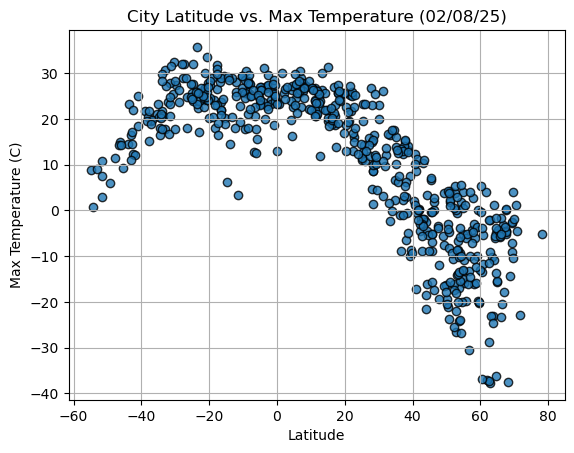

In [76]:
# Build scatter plot for latitude vs. temperature
plt.scatter(city_data_df["Lat"], city_data_df["Max Temp"], edgecolor="black", linewidths=1, marker="o", alpha=0.8, label="Cities")

# Incorporate the other graph properties
plt.title("City Latitude vs. Max Temperature (%s)" % time.strftime("%x"))
plt.ylabel("Max Temperature (C)")
plt.xlabel("Latitude")
plt.grid(True)

# Save the figure
plt.savefig("output_data/Fig1.png")

# Show plot
plt.show()

#### Latitude Vs. Humidity

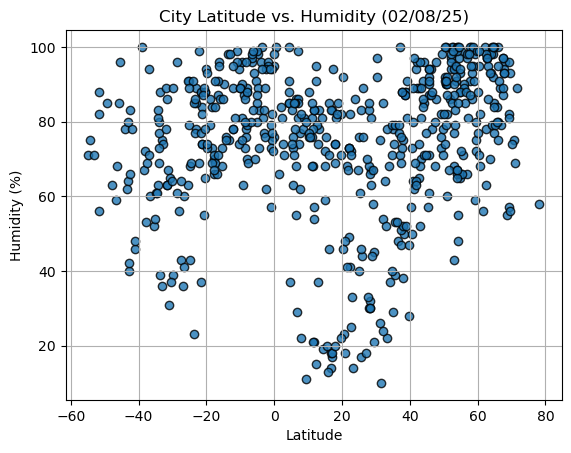

In [77]:
# Build the scatter plots for latitude vs. humidity
plt.scatter(city_data_df["Lat"], city_data_df["Humidity"], edgecolor="black", linewidths=1, marker="o", alpha=0.8, label="Cities")

# Incorporate the other graph properties
plt.title("City Latitude vs. Humidity (%s)" % time.strftime("%x"))
plt.ylabel("Humidity (%)")
plt.xlabel("Latitude")
plt.grid(True)

# Save the figure
plt.savefig("output_data/Fig2.png")

# Show plot
plt.show()

#### Latitude Vs. Cloudiness

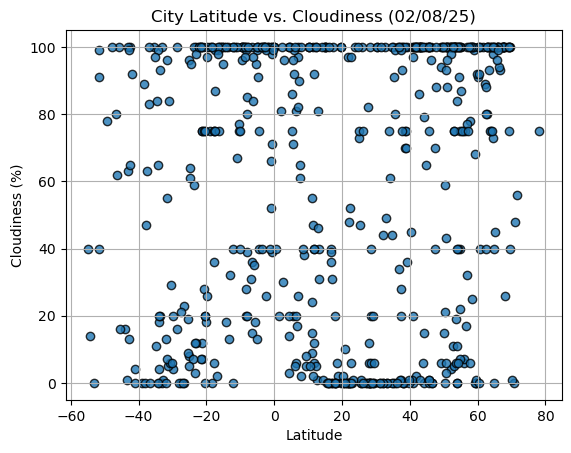

In [78]:
# Build the scatter plots for latitude vs. cloudiness
plt.scatter(city_data_df["Lat"], city_data_df["Cloudiness"], edgecolor="black", linewidths=1, marker="o", alpha=0.8, label="Cities")

# Incorporate the other graph properties
plt.title("City Latitude vs. Cloudiness (%s)" % time.strftime("%x"))
plt.ylabel("Cloudiness (%)")
plt.xlabel("Latitude")
plt.grid(True)

# Save the figure
plt.savefig("output_data/Fig3.png")

# Show plot
plt.show()

#### Latitude vs. Wind Speed Plot

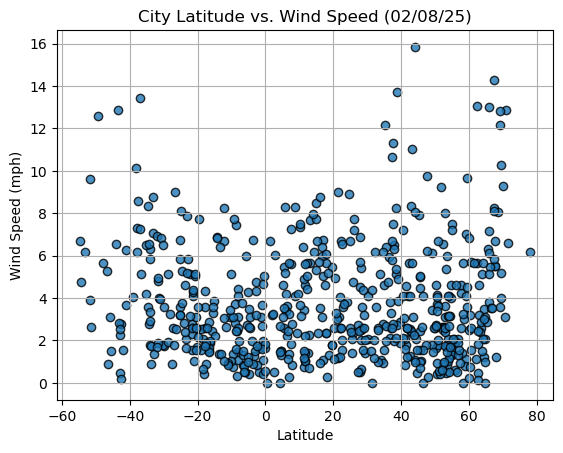

In [79]:
# Build the scatter plots for latitude vs. wind speed
plt.scatter(city_data_df["Lat"], city_data_df["Wind Speed"], edgecolor="black", linewidths=1, marker="o", alpha=0.8, label="Cities")

# Incorporate the other graph properties
plt.title("City Latitude vs. Wind Speed (%s)" % time.strftime("%x"))
plt.ylabel("Wind Speed (mph)")
plt.xlabel("Latitude")
plt.grid(True)

# Save the figure
plt.savefig("output_data/Fig4.png")

# Show plot
plt.show()

---

## Requirement 2: Compute Linear Regression for Each Relationship


In [80]:
# Define a function to create Linear Regression plots
def linear_regression(x_values, y_values):
    (slope, intercept, rvalue, pvalue, stderr) = linregress(x_values, y_values)
    regress_values = x_values * slope + intercept
    line_eq = "y = " + str(round(slope, 2)) + "x + " + str(round(intercept, 2))

    return slope, intercept, rvalue, pvalue, stderr, regress_values, line_eq

In [81]:
# Create a DataFrame with the Northern Hemisphere data (Latitude >= 0)
northern_hemi_df = city_data_df.loc[(city_data_df["Lat"] >= 0)]

# Display sample data
northern_hemi_df.head()

,City,Lat,Lng,Max Temp,Humidity,Cloudiness,Wind Speed,Country,Date
City_ID,,,,,,,,,
0,keflavik,64.0049,-22.5624,1.24,93,75,5.14,IS,1739062856
1,bethel,41.3712,-73.4140,-0.55,62,100,1.79,US,1739062801
7,ribeira grande,38.5167,-28.7000,13.22,88,75,8.23,PT,1739062864
9,whitehorse,60.7161,-135.0538,-11.66,82,40,1.54,CA,1739062867
11,laguna,38.4210,-121.4238,13.10,50,0,5.14,US,1739062869


In [82]:
# Create a DataFrame with the Southern Hemisphere data (Latitude < 0)
southern_hemi_df = city_data_df.loc[(city_data_df["Lat"] < 0)] 

# Display sample data
southern_hemi_df.head()

,City,Lat,Lng,Max Temp,Humidity,Cloudiness,Wind Speed,Country,Date
City_ID,,,,,,,,,
2,margaret river,-33.9500,115.0667,21.69,69,18,6.32,AU,1739062859
3,new plymouth,-39.0667,174.0833,21.84,100,0,4.03,NZ,1739062860
4,ushuaia,-54.8000,-68.3000,8.81,71,40,6.69,AR,1739062628
5,avarua,-21.2078,-159.7750,30.03,74,75,4.12,CK,1739062862
6,atafu village,-8.5421,-172.5159,28.40,73,100,7.45,TK,1739062863


###  Temperature vs. Latitude Linear Regression Plot

The r-value is: 0.7179020629661989


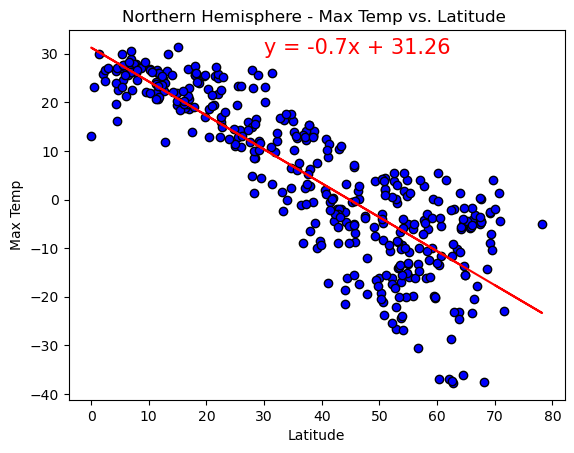

In [83]:
# Linear regression on Northern Hemisphere
x_values = northern_hemi_df["Lat"]
y_values = northern_hemi_df["Max Temp"]

# Call the function
slope, intercept, rvalue, pvalue, stderr, regress_values, line_eq = linear_regression(x_values, y_values)
print(f"The r-value is: {rvalue**2}")

# Create the plot
plt.scatter(x_values, y_values, color="blue", edgecolors="black")
plt.plot(x_values, regress_values, "r-")
plt.annotate(line_eq, (30, 30), fontsize=15, color="red")
plt.xlabel("Latitude")
plt.ylabel("Max Temp")
plt.title("Northern Hemisphere - Max Temp vs. Latitude ")
plt.show()



The r-value is: 0.21426268232955933


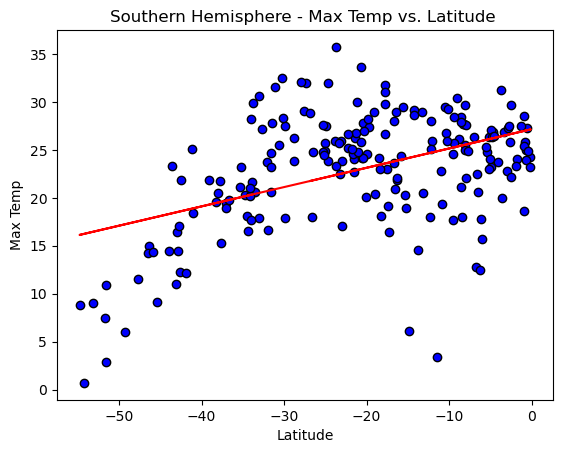

In [84]:
# Linear regression on Southern Hemisphere
x_values = southern_hemi_df["Lat"]
y_values = southern_hemi_df["Max Temp"]

# Call the function
slope, intercept, rvalue, pvalue, stderr, regress_values, line_eq = linear_regression(x_values, y_values)
print(f"The r-value is: {rvalue**2}")

# Create the plot
plt.scatter(x_values, y_values, color="blue", edgecolors="black")
plt.plot(x_values, regress_values, "r-")
plt.annotate(line_eq, (30, 30), fontsize=15, color="red")
plt.xlabel("Latitude")
plt.ylabel("Max Temp")
plt.title("Southern Hemisphere - Max Temp vs. Latitude ")
plt.show()

**Discussion about the linear relationship:** YOUR RESPONSE HERE

### Humidity vs. Latitude Linear Regression Plot

The r-value is: 0.14234517061799856


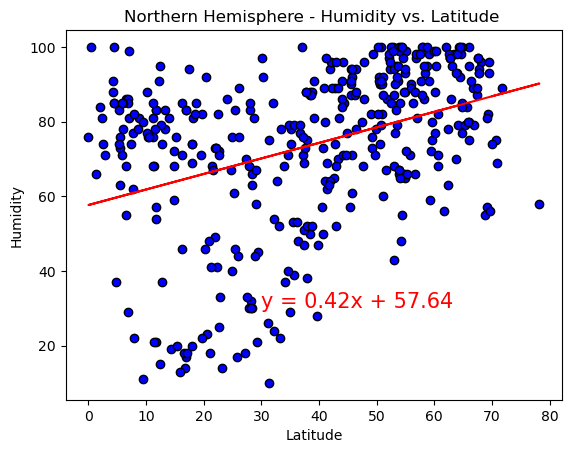

In [85]:
# Northern Hemisphere
x_values = northern_hemi_df["Lat"]
y_values = northern_hemi_df["Humidity"]

# Call the function
slope, intercept, rvalue, pvalue, stderr, regress_values, line_eq = linear_regression(x_values, y_values)
print(f"The r-value is: {rvalue**2}")

# Create the plot
plt.scatter(x_values, y_values, color="blue", edgecolors="black")
plt.plot(x_values, regress_values, "r-")
plt.annotate(line_eq, (30, 30), fontsize=15, color="red")
plt.xlabel("Latitude")
plt.ylabel("Humidity")
plt.title("Northern Hemisphere - Humidity vs. Latitude ")
plt.show()

The r-value is: 0.1663752252107184


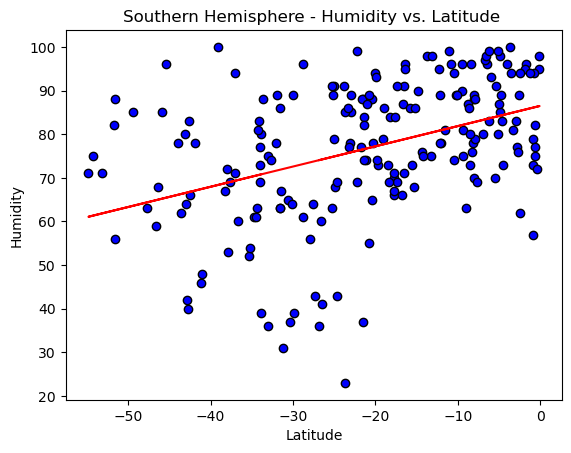

In [86]:
# Southern Hemisphere
x_values = southern_hemi_df["Lat"]
y_values = southern_hemi_df["Humidity"]

# Call the function
slope, intercept, rvalue, pvalue, stderr, regress_values, line_eq = linear_regression(x_values, y_values)
print(f"The r-value is: {rvalue**2}")

# Create the plot
plt.scatter(x_values, y_values, color="blue", edgecolors="black")
plt.plot(x_values, regress_values, "r-")
plt.annotate(line_eq, (30, 30), fontsize=15, color="red")
plt.xlabel("Latitude")
plt.ylabel("Humidity")
plt.title("Southern Hemisphere - Humidity vs. Latitude ")
plt.show()

**Discussion about the linear relationship:** YOUR RESPONSE HERE

### Cloudiness vs. Latitude Linear Regression Plot

The r-value is: 0.07640687181185203


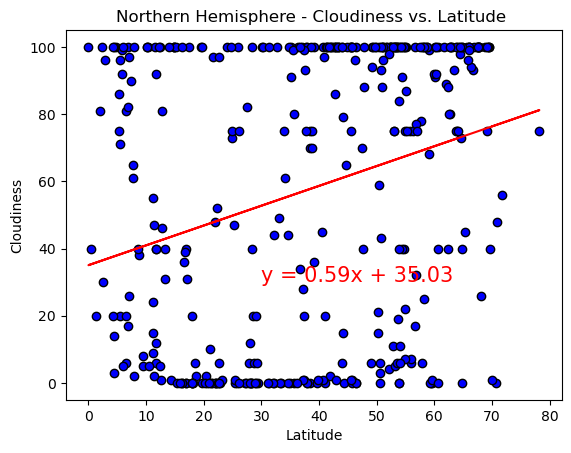

In [87]:
# Northern Hemisphere
x_values = northern_hemi_df["Lat"]
y_values = northern_hemi_df["Cloudiness"]

# Call the function
slope, intercept, rvalue, pvalue, stderr, regress_values, line_eq = linear_regression(x_values, y_values)
print(f"The r-value is: {rvalue**2}")

# Create the plot
plt.scatter(x_values, y_values, color="blue", edgecolors="black")
plt.plot(x_values, regress_values, "r-")
plt.annotate(line_eq, (30, 30), fontsize=15, color="red")
plt.xlabel("Latitude")
plt.ylabel("Cloudiness")
plt.title("Northern Hemisphere - Cloudiness vs. Latitude ")
plt.show()

The r-value is: 0.09310630895271793


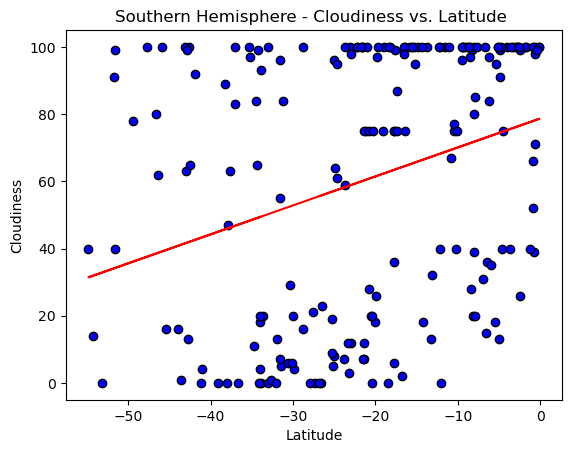

In [88]:
# Southern Hemisphere
x_values = southern_hemi_df["Lat"]
y_values = southern_hemi_df["Cloudiness"]

# Call the function
slope, intercept, rvalue, pvalue, stderr, regress_values, line_eq = linear_regression(x_values, y_values)
print(f"The r-value is: {rvalue**2}")

# Create the plot
plt.scatter(x_values, y_values, color="blue", edgecolors="black")
plt.plot(x_values, regress_values, "r-")
plt.annotate(line_eq, (30, 30), fontsize=15, color="red")
plt.xlabel("Latitude")
plt.ylabel("Cloudiness")
plt.title("Southern Hemisphere - Cloudiness vs. Latitude ")
plt.show()

**Discussion about the linear relationship:** YOUR RESPONSE HERE

### Wind Speed vs. Latitude Linear Regression Plot

The r-value is: 0.004656274318589971


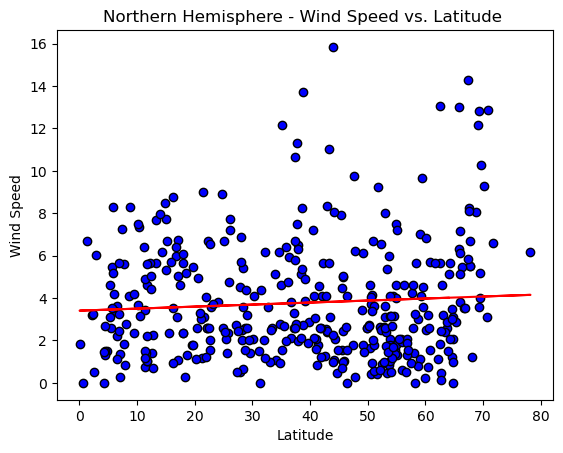

In [89]:
# Northern Hemisphere
x_values = northern_hemi_df["Lat"]
y_values = northern_hemi_df["Wind Speed"]

# Call the function
slope, intercept, rvalue, pvalue, stderr, regress_values, line_eq = linear_regression(x_values, y_values)
print(f"The r-value is: {rvalue**2}")

# Create the plot
plt.scatter(x_values, y_values, color="blue", edgecolors="black")
plt.plot(x_values, regress_values, "r-")
plt.annotate(line_eq, (30, 30), fontsize=15, color="red")
plt.xlabel("Latitude")
plt.ylabel("Wind Speed")
plt.title("Northern Hemisphere - Wind Speed vs. Latitude ")
plt.show()

The r-value is: 0.14788313997627267


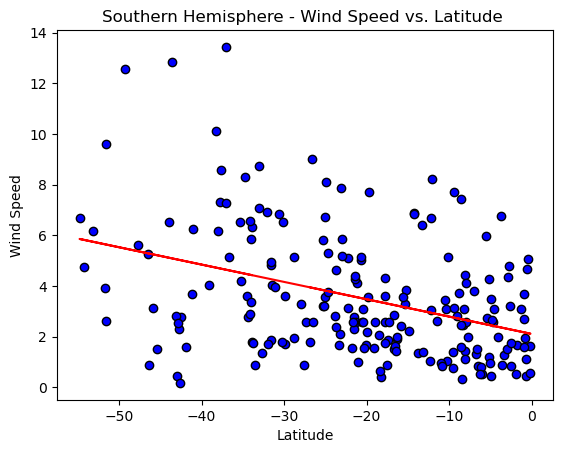

In [90]:
# Southern Hemisphere
x_values = southern_hemi_df["Lat"]
y_values = southern_hemi_df["Wind Speed"]

# Call the function
slope, intercept, rvalue, pvalue, stderr, regress_values, line_eq = linear_regression(x_values, y_values)
print(f"The r-value is: {rvalue**2}")

# Create the plot
plt.scatter(x_values, y_values, color="blue", edgecolors="black")
plt.plot(x_values, regress_values, "r-")
plt.annotate(line_eq, (30, 30), fontsize=15, color="red")
plt.xlabel("Latitude")
plt.ylabel("Wind Speed")
plt.title("Southern Hemisphere - Wind Speed vs. Latitude ")
plt.show()

**Discussion about the linear relationship:** YOUR RESPONSE HERE